<a href="https://colab.research.google.com/github/njwbilll/Tugas-1_Introduction-to-Machine-Learning-with-Python-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/04_Representing_Data_and_Engineering_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Merepresentasikan Data dan Rekayasa Fitur

**Referensi:** Introduction to Machine Learning with Python -- Andreas C. Muller & Sarah Guido (O'Reilly)

---

## Ringkasan Chapter

Kualitas fitur yang diberikan ke model seringkali lebih menentukan performa
daripada pilihan algoritma. Chapter ini membahas berbagai teknik untuk
mengubah dan menciptakan fitur yang lebih baik dari data mentah.

**Topik yang dibahas:**
- Variabel kategorikal: One-Hot Encoding dan Ordinal Encoding
- Binning (diskretisasi) fitur kontinu
- Interaction features dan Polynomial features
- Transformasi non-linear (log, sqrt)
- Seleksi fitur otomatis: univariate, model-based, iterative (RFE)


## 4.0 Import Library

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, KBinsDiscretizer,
    PolynomialFeatures, StandardScaler
)
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("Library berhasil diimport.")


Library berhasil diimport.


## 4.1 Variabel Kategorikal

Variabel kategorikal merepresentasikan kelompok atau kategori diskret.
Algoritma ML bekerja dengan angka, sehingga variabel kategorikal harus
dikonversi ke format numerik sebelum digunakan.

**Dua jenis variabel kategorikal:**

**Nominal (tidak berurutan)**
Tidak ada urutan alami antara kategori.
Contoh: warna (merah, biru, hijau), kota (Jakarta, Bandung, Surabaya), jenis kelamin.

**Ordinal (berurutan)**
Ada urutan alami antara kategori.
Contoh: pendidikan (SD < SMP < SMA < S1 < S2), rating (buruk < cukup < baik < sangat baik).

**Mengapa tidak bisa langsung pakai angka mentah?**
Jika kita encode Jakarta=1, Bandung=2, Surabaya=3, model akan mengasumsikan
Surabaya = 3x Jakarta, dan jarak Bandung-Surabaya = jarak Jakarta-Bandung.
Ini tidak bermakna untuk variabel nominal.


In [52]:
# Buat dataset contoh dengan variabel kategorikal
np.random.seed(42)
n = 200

df = pd.DataFrame({
    "kota"       : np.random.choice(["Jakarta", "Bandung", "Surabaya", "Medan"], n),
    "pendidikan" : np.random.choice(["SD", "SMP", "SMA", "S1", "S2"], n),
    "jenis_kelamin": np.random.choice(["Laki-laki", "Perempuan"], n),
    "usia"       : np.random.randint(18, 60, n),
    "penghasilan": np.random.randint(3_000_000, 20_000_000, n),
})

print("Dataset contoh:")
print(df.head(8))
print()
print("Tipe data:")
print(df.dtypes)
print()
print("Distribusi kolom 'kota':")
print(df["kota"].value_counts())


Dataset contoh:
       kota pendidikan jenis_kelamin  usia  penghasilan
0  Surabaya         SD     Perempuan    18     13155224
1     Medan         S1     Laki-laki    50      8001045
2   Jakarta         S2     Laki-laki    57      7463418
3  Surabaya         S1     Laki-laki    27     13270156
4  Surabaya         S2     Perempuan    46      7345760
5     Medan         S2     Perempuan    30      6251298
6   Jakarta        SMA     Laki-laki    29      7465150
7   Jakarta         S2     Laki-laki    48     10249903

Tipe data:
kota             object
pendidikan       object
jenis_kelamin    object
usia              int64
penghasilan       int64
dtype: object

Distribusi kolom 'kota':
kota
Surabaya    54
Medan       54
Jakarta     46
Bandung     46
Name: count, dtype: int64


## 4.2 One-Hot Encoding

One-Hot Encoding (OHE) adalah encoding standar untuk variabel nominal.
Setiap kategori unik diubah menjadi kolom biner baru.
Untuk setiap baris, tepat satu kolom bernilai 1 dan sisanya 0.

**Contoh:**
kota = "Jakarta"  -->  jakarta=1, bandung=0, surabaya=0, medan=0
kota = "Bandung"  -->  jakarta=0, bandung=1, surabaya=0, medan=0

**Drop first (menghindari dummy variable trap):**
Untuk model linear, kita perlu membuang satu kolom per fitur kategorikal
untuk menghindari multikolinearitas sempurna (dummy variable trap).
Misal dengan 4 kota, cukup 3 kolom -- kota ke-4 bisa disimpulkan dari ketiga lainnya.
Untuk tree-based model, ini tidak diperlukan.

**Kelemahan OHE:**
Jika fitur punya banyak kategori unik (high cardinality), OHE menghasilkan
sangat banyak kolom baru (bisa ratusan atau ribuan).


In [53]:
# One-Hot Encoding menggunakan pandas get_dummies
df_dummies = pd.get_dummies(df, columns=["kota", "jenis_kelamin"], drop_first=False)

print("Shape sebelum OHE:", df.shape)
print("Shape setelah OHE :", df_dummies.shape)
print()
print("Kolom baru yang terbentuk:")
new_cols = [c for c in df_dummies.columns if c not in df.columns]
print(new_cols)
print()
print("5 baris pertama (kolom kota):")
kota_cols = [c for c in df_dummies.columns if "kota" in c]
print(df_dummies[kota_cols].head(6).to_string())


Shape sebelum OHE: (200, 5)
Shape setelah OHE : (200, 9)

Kolom baru yang terbentuk:
['kota_Bandung', 'kota_Jakarta', 'kota_Medan', 'kota_Surabaya', 'jenis_kelamin_Laki-laki', 'jenis_kelamin_Perempuan']

5 baris pertama (kolom kota):
   kota_Bandung  kota_Jakarta  kota_Medan  kota_Surabaya
0         False         False       False           True
1         False         False        True          False
2         False          True       False          False
3         False         False       False           True
4         False         False       False           True
5         False         False        True          False


In [54]:
# One-Hot Encoding menggunakan scikit-learn OneHotEncoder (direkomendasikan untuk pipeline)
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop="first")
kota_encoded = ohe.fit_transform(df[["kota"]])

print("=== OneHotEncoder (scikit-learn) ===")
print("Kategori yang dipelajari:", ohe.categories_)
print("Nama fitur output:", ohe.get_feature_names_out())
print()
print("5 baris pertama hasil encoding:")
df_ohe = pd.DataFrame(kota_encoded, columns=ohe.get_feature_names_out())
print(df_ohe.head(6).to_string())
print()
print("Dengan drop='first', kolom 'Bandung' dibuang sebagai referensi.")
print("Jika kota_Jakarta=0, kota_Medan=0, kota_Surabaya=0 --> kota = Bandung.")


=== OneHotEncoder (scikit-learn) ===
Kategori yang dipelajari: [array(['Bandung', 'Jakarta', 'Medan', 'Surabaya'], dtype=object)]
Nama fitur output: ['kota_Jakarta' 'kota_Medan' 'kota_Surabaya']

5 baris pertama hasil encoding:
   kota_Jakarta  kota_Medan  kota_Surabaya
0           0.0         0.0            1.0
1           0.0         1.0            0.0
2           1.0         0.0            0.0
3           0.0         0.0            1.0
4           0.0         0.0            1.0
5           0.0         1.0            0.0

Dengan drop='first', kolom 'Bandung' dibuang sebagai referensi.
Jika kota_Jakarta=0, kota_Medan=0, kota_Surabaya=0 --> kota = Bandung.


## 4.3 Ordinal Encoding

Untuk variabel ordinal, kita bisa memberikan nilai numerik yang mencerminkan urutan.
Berbeda dengan OHE, Ordinal Encoding mempertahankan informasi urutan.

**Kapan menggunakan Ordinal Encoding:**
- Variabel memiliki urutan yang bermakna (pendidikan, rating, ukuran)
- Jumlah kategori banyak (OHE menghasilkan terlalu banyak kolom)
- Digunakan dengan tree-based model yang bisa menangkap urutan

**Perhatian:**
Jangan gunakan Ordinal Encoding untuk variabel nominal! Model akan mengasumsikan
ada hubungan numerik antar kategori yang sebenarnya tidak ada.


In [55]:
from sklearn.preprocessing import OrdinalEncoder

# Definisikan urutan yang benar untuk pendidikan
pendidikan_order = [["SD", "SMP", "SMA", "S1", "S2"]]

oe = OrdinalEncoder(categories=pendidikan_order)
df["pendidikan_encoded"] = oe.fit_transform(df[["pendidikan"]])

print("Ordinal Encoding untuk 'pendidikan':")
print("Urutan kategori:", pendidikan_order[0])
print()
# Tampilkan mapping
mapping_df = pd.DataFrame({
    "Kategori": pendidikan_order[0],
    "Nilai Numerik": range(len(pendidikan_order[0]))
})
print(mapping_df.to_string(index=False))
print()
print("Contoh hasil encoding:")
sample = df[["pendidikan", "pendidikan_encoded"]].drop_duplicates().sort_values("pendidikan_encoded")
print(sample.to_string(index=False))


Ordinal Encoding untuk 'pendidikan':
Urutan kategori: ['SD', 'SMP', 'SMA', 'S1', 'S2']

Kategori  Nilai Numerik
      SD              0
     SMP              1
     SMA              2
      S1              3
      S2              4

Contoh hasil encoding:
pendidikan  pendidikan_encoded
        SD                 0.0
       SMP                 1.0
       SMA                 2.0
        S1                 3.0
        S2                 4.0


In [56]:
# Perbandingan OHE vs Ordinal pada model klasifikasi
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Buat dataset sederhana untuk klasifikasi
np.random.seed(0)
n_samples = 500
education_map = {"SD": 0, "SMP": 1, "SMA": 2, "S1": 3, "S2": 4}
edu_raw = np.random.choice(list(education_map.keys()), n_samples)
edu_num = np.array([education_map[e] for e in edu_raw])
# Target: probabilitas memiliki penghasilan tinggi meningkat dengan pendidikan
y_prob = edu_num / 4 * 0.7 + np.random.rand(n_samples) * 0.3
y_clf = (y_prob > 0.5).astype(int)

df_edu = pd.DataFrame({"pendidikan": edu_raw})

# OHE
ohe_edu = OneHotEncoder(sparse_output=False)
X_ohe = ohe_edu.fit_transform(df_edu)

# Ordinal
oe_edu = OrdinalEncoder(categories=[["SD", "SMP", "SMA", "S1", "S2"]])
X_ord = oe_edu.fit_transform(df_edu)

X_ohe_tr, X_ohe_te, y_tr, y_te = train_test_split(X_ohe, y_clf, random_state=0)
X_ord_tr, X_ord_te, _, _       = train_test_split(X_ord, y_clf, random_state=0)

# Uji dengan Logistic Regression (sensitif terhadap encoding)
lr = LogisticRegression()
lr.fit(X_ohe_tr, y_tr)
acc_ohe = lr.score(X_ohe_te, y_te)

lr.fit(X_ord_tr, y_tr)
acc_ord = lr.score(X_ord_te, y_te)

print("Perbandingan encoding pada Logistic Regression:")
print(f"  One-Hot Encoding  : {acc_ohe:.4f}")
print(f"  Ordinal Encoding  : {acc_ord:.4f}")
print()
print("Untuk variabel dengan urutan alami, Ordinal Encoding bisa lebih baik")
print("karena model linear bisa memanfaatkan informasi urutan secara langsung.")


Perbandingan encoding pada Logistic Regression:
  One-Hot Encoding  : 0.9360
  Ordinal Encoding  : 0.9360

Untuk variabel dengan urutan alami, Ordinal Encoding bisa lebih baik
karena model linear bisa memanfaatkan informasi urutan secara langsung.


## 4.4 Binning (Diskretisasi) Fitur Kontinu

Binning mengubah fitur kontinu menjadi kategori diskret (interval/bin).
Setiap sampel dimasukkan ke dalam bin yang sesuai berdasarkan nilainya.

**Strategi binning:**
- **uniform**: setiap bin punya lebar yang sama
- **quantile**: setiap bin punya jumlah sampel yang sama
- **kmeans**: posisi bin ditentukan oleh k-Means clustering 1D

**Kapan binning berguna:**
- Model linear yang perlu menangkap hubungan non-linear
  (setiap bin bisa punya koefisien berbeda)
- Ketika domain knowledge menunjukkan ada threshold bermakna
  (misal: usia < 18 = anak, 18-65 = dewasa, > 65 = lansia)
- Mengurangi efek outlier

**Kapan binning tidak perlu:**
- Tree-based models sudah menemukan split point secara otomatis
- Data sudah memiliki hubungan linear yang jelas


In [57]:
from sklearn.preprocessing import KBinsDiscretizer

# Dataset regresi non-linear 1D
np.random.seed(0)
X_cont = np.random.uniform(-3, 3, (200, 1))
y_cont = np.sin(X_cont.ravel()) + np.random.randn(200) * 0.25

# Binning dengan 10 bins
kbd = KBinsDiscretizer(n_bins=10, encode="onehot-dense", strategy="uniform")
X_binned = kbd.fit_transform(X_cont)

print("=== KBinsDiscretizer ===")
print(f"Shape fitur asli   : {X_cont.shape}")
print(f"Shape setelah binning: {X_binned.shape}")
print()
print(f"Tepi-tepi bin:")
print(np.round(kbd.bin_edges_[0], 3))


=== KBinsDiscretizer ===
Shape fitur asli   : (200, 1)
Shape setelah binning: (200, 10)

Tepi-tepi bin:
[-2.972 -2.375 -1.779 -1.182 -0.586  0.011  0.607  1.204  1.8    2.397
  2.993]


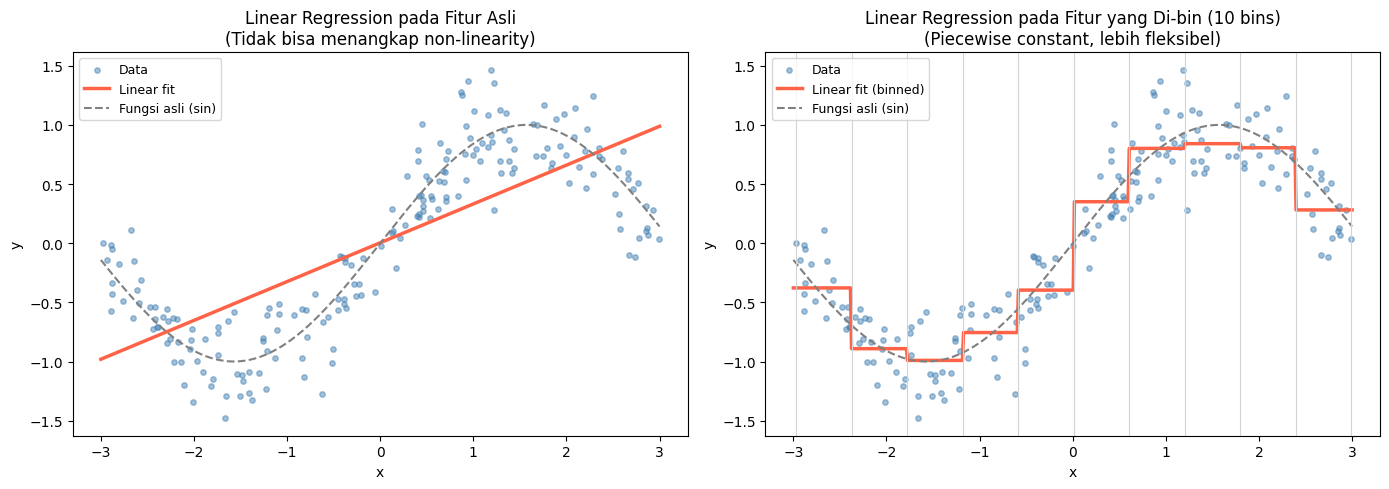

R2 fitur asli    : 0.5682
R2 fitur binned  : 0.8795


In [58]:
# Visualisasi: Linear Regression pada fitur asli vs fitur yang di-bin
from sklearn.linear_model import LinearRegression

lr_raw    = LinearRegression().fit(X_cont, y_cont)
lr_binned = LinearRegression().fit(X_binned, y_cont)

X_plot = np.linspace(-3, 3, 500).reshape(-1, 1)
X_plot_binned = kbd.transform(X_plot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_cont, y_cont, s=15, alpha=0.5, color="steelblue", label="Data")
axes[0].plot(X_plot, lr_raw.predict(X_plot), color="tomato", linewidth=2.5,
             label="Linear fit")
axes[0].plot(X_plot, np.sin(X_plot.ravel()), color="gray", linewidth=1.5,
             linestyle="--", label="Fungsi asli (sin)")
axes[0].set_title("Linear Regression pada Fitur Asli\n(Tidak bisa menangkap non-linearity)")
axes[0].legend(fontsize=9)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].scatter(X_cont, y_cont, s=15, alpha=0.5, color="steelblue", label="Data")
axes[1].plot(X_plot, lr_binned.predict(X_plot_binned), color="tomato", linewidth=2.5,
             label="Linear fit (binned)")
axes[1].plot(X_plot, np.sin(X_plot.ravel()), color="gray", linewidth=1.5,
             linestyle="--", label="Fungsi asli (sin)")
for edge in kbd.bin_edges_[0]:
    axes[1].axvline(edge, color="lightgray", linewidth=0.8)
axes[1].set_title("Linear Regression pada Fitur yang Di-bin (10 bins)\n(Piecewise constant, lebih fleksibel)")
axes[1].legend(fontsize=9)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

print(f"R2 fitur asli    : {lr_raw.score(X_cont, y_cont):.4f}")
print(f"R2 fitur binned  : {lr_binned.score(X_binned, y_cont):.4f}")


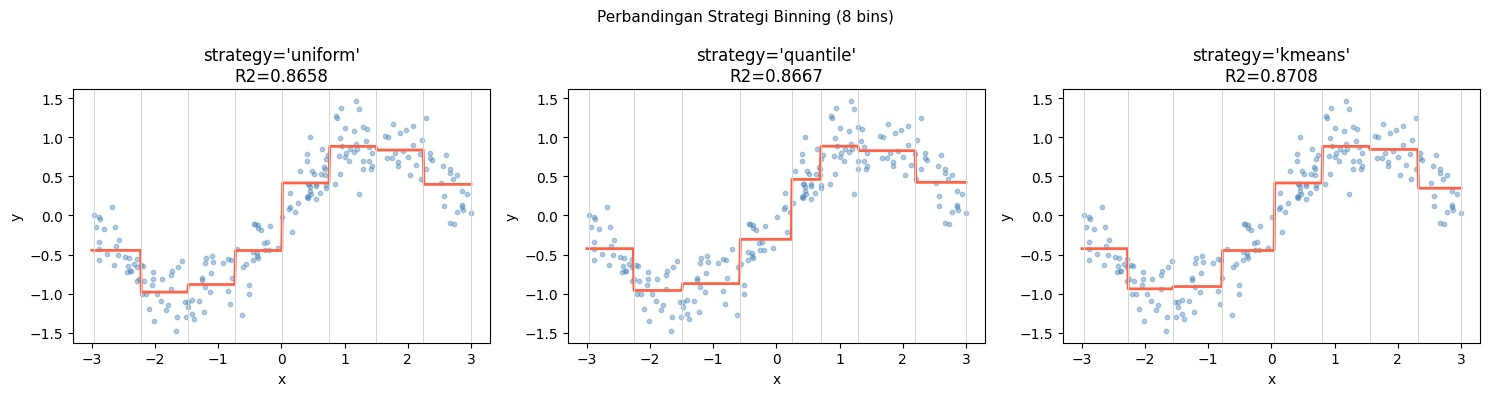

In [59]:
# Perbandingan strategi binning
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
strategies = ["uniform", "quantile", "kmeans"]

for ax, strategy in zip(axes, strategies):
    kbd_s = KBinsDiscretizer(n_bins=8, encode="onehot-dense", strategy=strategy)
    X_b = kbd_s.fit_transform(X_cont)
    lr_s = LinearRegression().fit(X_b, y_cont)

    ax.scatter(X_cont, y_cont, s=10, alpha=0.4, color="steelblue")
    ax.plot(X_plot, lr_s.predict(kbd_s.transform(X_plot)),
            color="tomato", linewidth=2)
    for edge in kbd_s.bin_edges_[0]:
        ax.axvline(edge, color="lightgray", linewidth=0.7)
    ax.set_title(f"strategy='{strategy}'\nR2={lr_s.score(X_b, y_cont):.4f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Perbandingan Strategi Binning (8 bins)", fontsize=11)
plt.tight_layout()
plt.show()


## 4.5 Interaction Features dan Polynomial Features

### Interaction Features

Fitur interaksi menangkap efek gabungan dari dua atau lebih fitur.
Model linear tidak bisa secara langsung menangkap interaksi -- ia hanya bisa
memodelkan efek setiap fitur secara independen.

Jika pengaruh fitur A bergantung pada nilai fitur B, kita butuh fitur interaksi A*B.

**Contoh nyata:**
- Harga properti: (luas tanah) * (lokasi premium) bukan hanya luas + lokasi
- Efektivitas obat: (dosis) * (berat badan pasien)

### Polynomial Features

`PolynomialFeatures` membuat semua kombinasi perkalian fitur hingga derajat tertentu.

Untuk fitur [x1, x2] dengan degree=2:
Output: [1, x1, x2, x1^2, x1*x2, x2^2]

**Trade-off:**
- Degree lebih tinggi = model lebih fleksibel = risiko overfitting lebih besar
- Jumlah fitur meledak: p fitur dengan degree d menghasilkan O(p^d) fitur baru


In [60]:
from sklearn.preprocessing import PolynomialFeatures

# Dataset 2D dengan interaksi non-linear
np.random.seed(42)
X_inter = np.random.uniform(-2, 2, (200, 2))
# Target bergantung pada interaksi: y = x1^2 + 2*x1*x2 + noise
y_inter = X_inter[:, 0]**2 + 2*X_inter[:, 0]*X_inter[:, 1] + np.random.randn(200)*0.3

print("=== PolynomialFeatures ===")
for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_inter)
    print(f"Degree={degree}: {X_inter.shape[1]} fitur asli --> {X_poly.shape[1]} fitur")
    if degree == 2:
        print(f"  Nama fitur: {poly.get_feature_names_out()}")


=== PolynomialFeatures ===
Degree=1: 2 fitur asli --> 2 fitur
Degree=2: 2 fitur asli --> 5 fitur
  Nama fitur: ['x0' 'x1' 'x0^2' 'x0 x1' 'x1^2']
Degree=3: 2 fitur asli --> 9 fitur


In [61]:
# Uji performa: Linear Regression dengan berbagai degree polynomial
from sklearn.model_selection import cross_val_score

print("Performa Linear Regression + Polynomial Features (5-fold CV R2):")
print(f"{'Degree':<10} {'Fitur':>8} {'Train R2':>12} {'CV R2':>12}")
print("-" * 45)

for degree in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_p = poly.fit_transform(X_inter)
    lr = LinearRegression()

    cv_scores = cross_val_score(lr, X_p, y_inter, cv=5, scoring="r2")
    lr.fit(X_p, y_inter)
    train_r2 = lr.score(X_p, y_inter)

    print(f"{degree:<10} {X_p.shape[1]:>8} {train_r2:>12.4f} {cv_scores.mean():>12.4f}")

print()
print("Degree 2 sesuai karena fungsi aslinya memang kuadratik.")
print("Degree 3 dan 4 overfitting (train R2 tinggi, CV R2 tidak membaik).")


Performa Linear Regression + Polynomial Features (5-fold CV R2):
Degree        Fitur     Train R2        CV R2
---------------------------------------------
1                 2       0.0043      -0.0800
2                 5       0.9904       0.9888
3                 9       0.9910       0.9892
4                14       0.9911       0.9883

Degree 2 sesuai karena fungsi aslinya memang kuadratik.
Degree 3 dan 4 overfitting (train R2 tinggi, CV R2 tidak membaik).


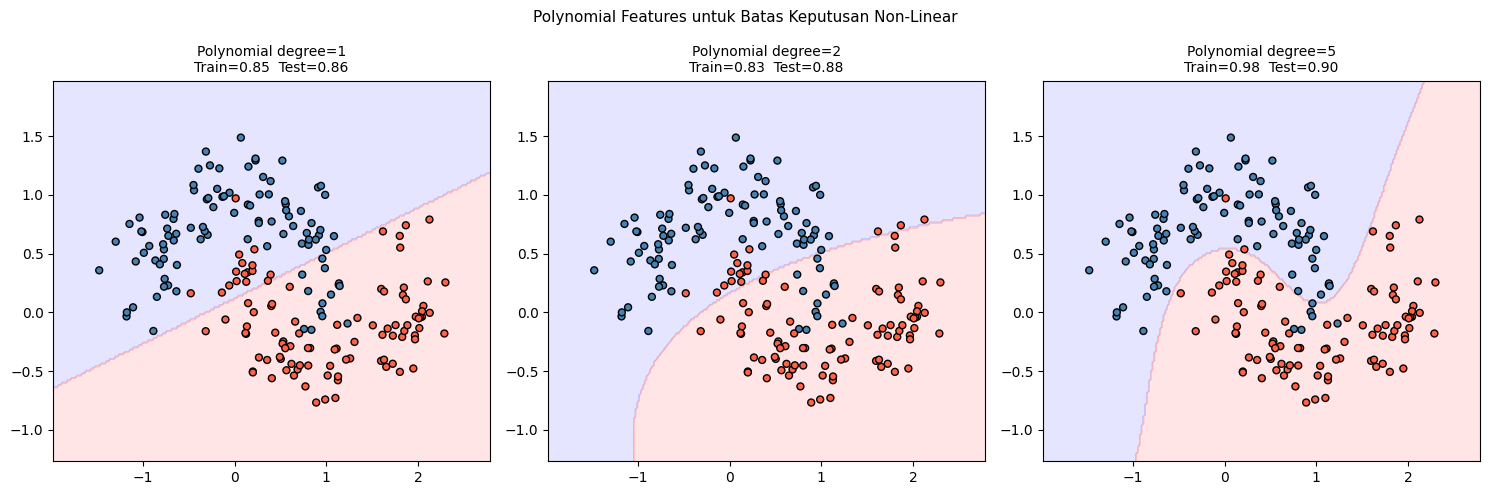

In [62]:
# Visualisasi batas keputusan dengan polynomial features (klasifikasi)
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression

X_moon, y_moon = make_moons(n_samples=200, noise=0.2, random_state=42)
X_mtr, X_mte, y_mtr, y_mte = train_test_split(X_moon, y_moon, random_state=0)

from matplotlib.colors import ListedColormap

def plot_boundary(model, X, y, ax, title):
    h = 0.02
    x0_min, x0_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
    x1_min, x1_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                          np.arange(x1_min, x1_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(["#AAAAFF","#FFAAAA"]))
    ax.scatter(X[:,0], X[:,1], c=y, cmap=ListedColormap(["steelblue","tomato"]),
               edgecolors="k", s=25)
    ax.set_title(title, fontsize=10)

from sklearn.pipeline import make_pipeline

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, degree in zip(axes, [1, 2, 5]):
    pipe = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LogisticRegression(max_iter=5000, C=1)
    )
    pipe.fit(X_mtr, y_mtr)
    tr = pipe.score(X_mtr, y_mtr)
    te = pipe.score(X_mte, y_mte)
    plot_boundary(pipe, X_moon, y_moon, ax,
        f"Polynomial degree={degree}\nTrain={tr:.2f}  Test={te:.2f}")

plt.suptitle("Polynomial Features untuk Batas Keputusan Non-Linear", fontsize=11)
plt.tight_layout()
plt.show()


## 4.6 Transformasi Non-Linear Univariat

Banyak fitur dunia nyata memiliki distribusi yang sangat miring (skewed),
terutama data finansial, populasi, dan hitungan (count data).
Transformasi dapat membuat distribusi lebih simetris dan membantu model linear.

**Transformasi umum:**

**log1p (log(1 + x))**
- Mengkompres nilai besar, memperluas nilai kecil
- Cocok untuk: hitungan, harga, pendapatan, populasi
- Mengapa +1? Agar bisa menangani nilai 0 (log(0) tidak terdefinisi)

**sqrt (akar kuadrat)**
- Kompresi lebih ringan dari log
- Cocok untuk: data Poisson (hitungan kejadian)

**exp dan log**
- Berguna untuk membalik transformasi sebelumnya

**Catatan penting:**
Tree-based models (Decision Tree, Random Forest, Gradient Boosting) tidak
terpengaruh oleh transformasi monoton karena mereka hanya peduli dengan
urutan relatif nilai, bukan nilai absolutnya. Transformasi terutama membantu
model linear dan neural network.


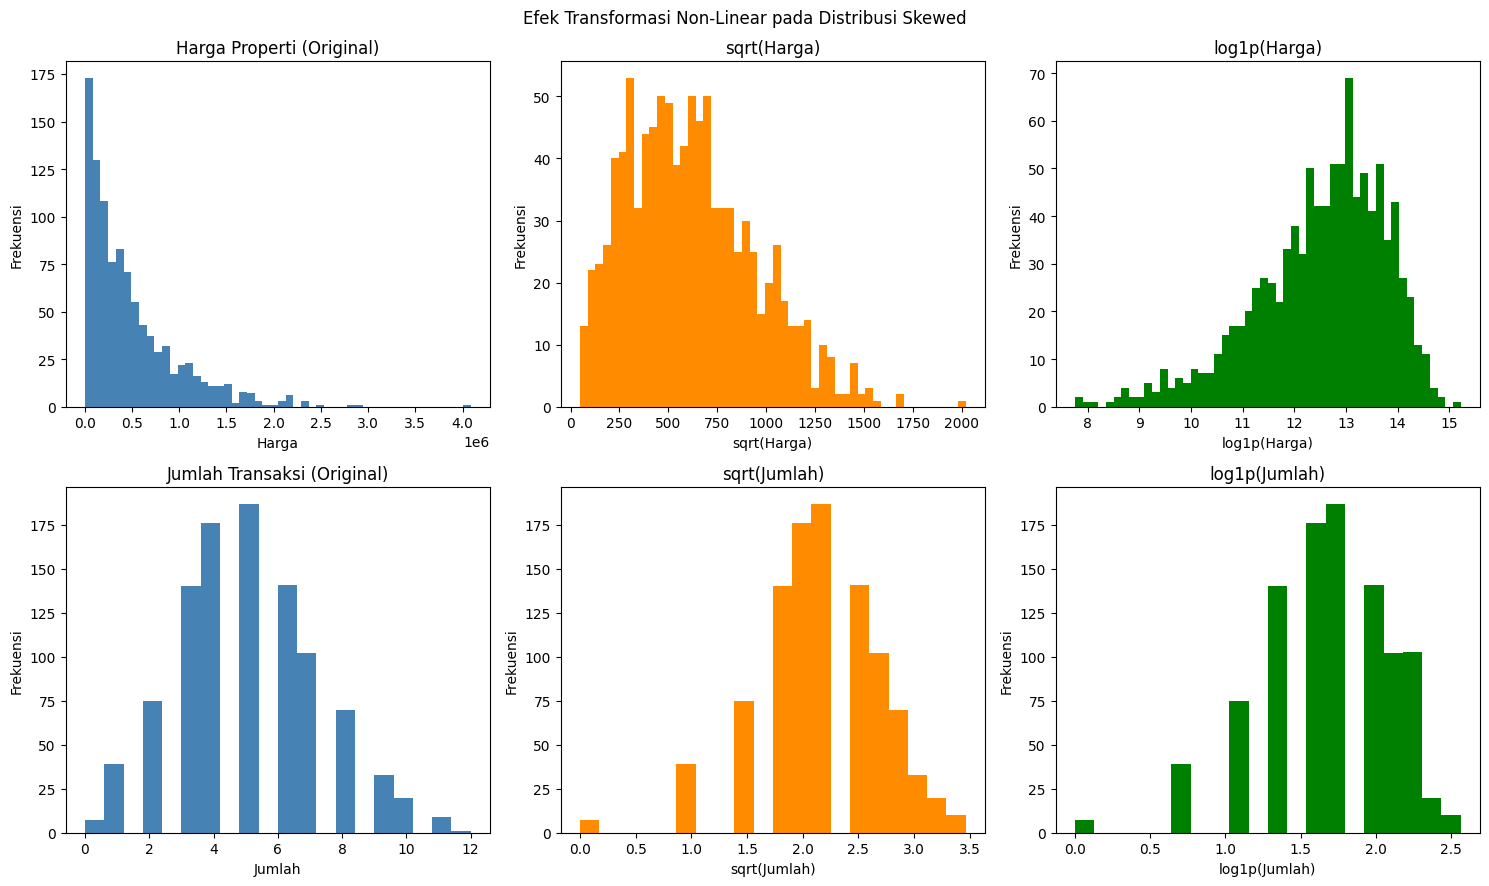

In [63]:
# Simulasi distribusi skewed
np.random.seed(42)
harga  = np.random.exponential(scale=500_000, size=1000)  # harga properti
jumlah = np.random.poisson(lam=5, size=1000)               # jumlah transaksi

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Harga
axes[0, 0].hist(harga, bins=50, color="steelblue", edgecolor="none")
axes[0, 0].set_title("Harga Properti (Original)")
axes[0, 0].set_xlabel("Harga")

axes[0, 1].hist(np.sqrt(harga), bins=50, color="darkorange", edgecolor="none")
axes[0, 1].set_title("sqrt(Harga)")
axes[0, 1].set_xlabel("sqrt(Harga)")

axes[0, 2].hist(np.log1p(harga), bins=50, color="green", edgecolor="none")
axes[0, 2].set_title("log1p(Harga)")
axes[0, 2].set_xlabel("log1p(Harga)")

# Jumlah transaksi
axes[1, 0].hist(jumlah, bins=20, color="steelblue", edgecolor="none")
axes[1, 0].set_title("Jumlah Transaksi (Original)")
axes[1, 0].set_xlabel("Jumlah")

axes[1, 1].hist(np.sqrt(jumlah), bins=20, color="darkorange", edgecolor="none")
axes[1, 1].set_title("sqrt(Jumlah)")
axes[1, 1].set_xlabel("sqrt(Jumlah)")

axes[1, 2].hist(np.log1p(jumlah), bins=20, color="green", edgecolor="none")
axes[1, 2].set_title("log1p(Jumlah)")
axes[1, 2].set_xlabel("log1p(Jumlah)")

for ax in axes.ravel():
    ax.set_ylabel("Frekuensi")

plt.suptitle("Efek Transformasi Non-Linear pada Distribusi Skewed", fontsize=12)
plt.tight_layout()
plt.show()


Perbandingan Linear Regression: fitur asli vs log-transformed
  Test R2 (fitur asli)          : 0.8021
  Test R2 (log1p fitur)         : 0.9706


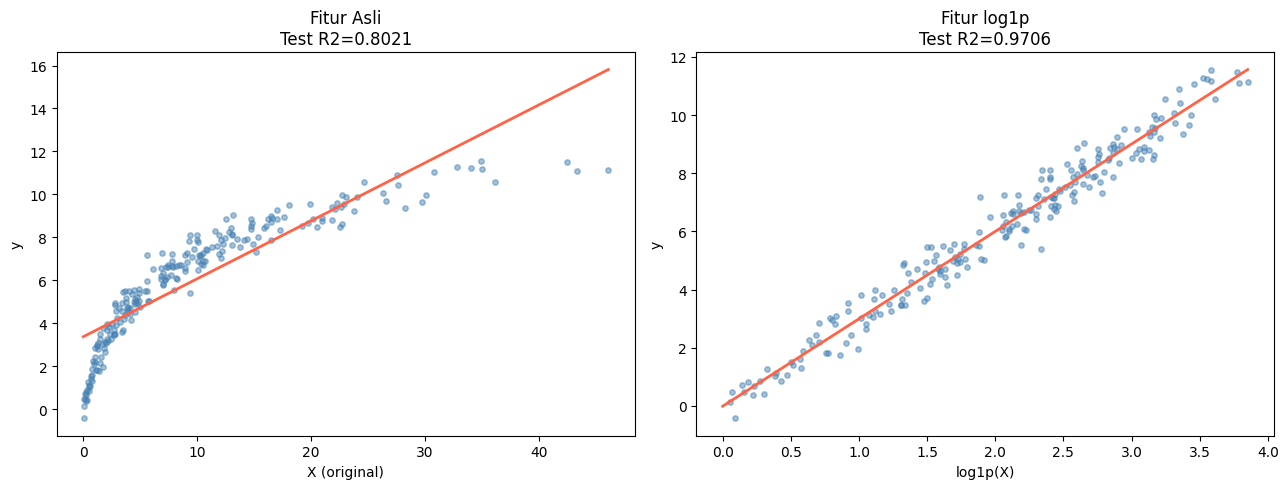

In [64]:
# Dampak transformasi log pada model linear
np.random.seed(42)
n = 300
X_skew = np.random.exponential(scale=10, size=(n, 1))
# Target: hubungan linear dengan log(X)
y_skew = 3 * np.log1p(X_skew.ravel()) + np.random.randn(n) * 0.5

X_skew_tr, X_skew_te, y_skew_tr, y_skew_te = train_test_split(
    X_skew, y_skew, random_state=0)

# Linear Regression pada X asli
lr_raw = LinearRegression().fit(X_skew_tr, y_skew_tr)

# Linear Regression pada log1p(X)
X_log_tr = np.log1p(X_skew_tr)
X_log_te = np.log1p(X_skew_te)
lr_log = LinearRegression().fit(X_log_tr, y_skew_tr)

print("Perbandingan Linear Regression: fitur asli vs log-transformed")
print(f"  Test R2 (fitur asli)          : {lr_raw.score(X_skew_te, y_skew_te):.4f}")
print(f"  Test R2 (log1p fitur)         : {lr_log.score(X_log_te, y_skew_te):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
X_plot_raw = np.linspace(0, X_skew.max(), 200).reshape(-1, 1)

axes[0].scatter(X_skew_tr, y_skew_tr, s=15, alpha=0.5, color="steelblue")
axes[0].plot(X_plot_raw, lr_raw.predict(X_plot_raw), color="tomato", linewidth=2)
axes[0].set_title(f"Fitur Asli\nTest R2={lr_raw.score(X_skew_te, y_skew_te):.4f}")
axes[0].set_xlabel("X (original)")
axes[0].set_ylabel("y")

axes[1].scatter(np.log1p(X_skew_tr), y_skew_tr, s=15, alpha=0.5, color="steelblue")
X_plot_log = np.log1p(X_plot_raw)
axes[1].plot(X_plot_log, lr_log.predict(X_plot_log), color="tomato", linewidth=2)
axes[1].set_title(f"Fitur log1p\nTest R2={lr_log.score(X_log_te, y_skew_te):.4f}")
axes[1].set_xlabel("log1p(X)")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()


## 4.7 Seleksi Fitur Otomatis

Dengan banyak fitur, beberapa mungkin tidak relevan atau redundan.
Seleksi fitur dapat mengurangi overfitting, mempercepat training,
dan meningkatkan interpretabilitas.

**Tiga strategi seleksi fitur:**

### 1. Univariate Statistics (Filter Methods)
Menguji setiap fitur secara independen terhadap target.
Fitur dengan skor statistik terbaik dipilih.
- `f_classif`: uji F (ANOVA) untuk klasifikasi -- mengukur perbedaan rata-rata antar kelas
- `mutual_info_classif`: mutual information -- mengukur ketergantungan statistik
- `f_regression`: uji F untuk regresi
- Cepat tapi mengabaikan interaksi antar fitur

### 2. Model-Based Selection
Melatih satu model dan menggunakan importance-nya untuk memilih fitur.
- Random Forest / Gradient Boosting: `feature_importances_`
- Model L1 (Lasso, Linear SVM L1): koefisien = 0 untuk fitur tidak relevan
- Lebih baik dari univariate karena mempertimbangkan interaksi

### 3. Iterative Selection (RFE -- Recursive Feature Elimination)
Melatih model, membuang fitur paling tidak penting, ulangi.
- Lebih mahal secara komputasi tapi sering menghasilkan subset fitur terbaik
- `RFECV` otomatis memilih jumlah fitur optimal via cross-validation


In [65]:
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel, RFE
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_tr, X_te, y_tr, y_te = train_test_split(
    cancer.data, cancer.target, random_state=0, stratify=cancer.target)

print(f"Dataset: {cancer.data.shape[0]} sampel, {cancer.data.shape[1]} fitur")
print()

# 1. Univariate selection
print("=== 1. Univariate Feature Selection (SelectKBest, f_classif, k=15) ===")
select_uni = SelectKBest(score_func=f_classif, k=15)
select_uni.fit(X_tr, y_tr)

uni_scores = pd.Series(select_uni.scores_, index=cancer.feature_names)
selected_uni = cancer.feature_names[select_uni.get_support()]
print("Top 10 fitur berdasarkan F-score:")
print(uni_scores.nlargest(10).round(2).to_string())


Dataset: 569 sampel, 30 fitur

=== 1. Univariate Feature Selection (SelectKBest, f_classif, k=15) ===
Top 10 fitur berdasarkan F-score:
worst concave points    797.03
mean concave points     704.49
worst perimeter         685.82
worst radius            656.81
mean perimeter          543.36
mean radius             505.18
mean concavity          491.12
worst area              488.44
mean area               432.99
worst concavity         354.69


In [66]:
# 2. Model-based selection
print("=== 2. Model-Based Feature Selection (RandomForest) ===")
rf_sel = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
select_model = SelectFromModel(rf_sel, threshold="median")
select_model.fit(X_tr, y_tr)

selected_model = cancer.feature_names[select_model.get_support()]
rf_importances = pd.Series(
    select_model.estimator_.feature_importances_,
    index=cancer.feature_names
)

print(f"Jumlah fitur terpilih: {len(selected_model)} dari {cancer.data.shape[1]}")
print("Top 10 fitur berdasarkan importance:")
print(rf_importances.nlargest(10).round(4).to_string())


=== 2. Model-Based Feature Selection (RandomForest) ===
Jumlah fitur terpilih: 15 dari 30
Top 10 fitur berdasarkan importance:
worst perimeter         0.1954
worst radius            0.1254
worst concave points    0.1015
mean concave points     0.0920
mean concavity          0.0806
worst area              0.0744
mean perimeter          0.0693
mean area               0.0411
mean radius             0.0297
area error              0.0230


In [67]:
# 3. RFE (Recursive Feature Elimination)
print("=== 3. Recursive Feature Elimination (RFE, k=15) ===")
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc  = sc.transform(X_te)

rfe = RFE(estimator=LogisticRegression(max_iter=5000, C=1),
           n_features_to_select=15, step=1)
rfe.fit(X_tr_sc, y_tr)

selected_rfe = cancer.feature_names[rfe.get_support()]
print(f"Jumlah fitur terpilih: {len(selected_rfe)} dari {cancer.data.shape[1]}")
print("Fitur terpilih:")
for i, f in enumerate(selected_rfe):
    print(f"  {i+1:2d}. {f}")


=== 3. Recursive Feature Elimination (RFE, k=15) ===
Jumlah fitur terpilih: 15 dari 30
Fitur terpilih:
   1. mean radius
   2. mean area
   3. mean concavity
   4. mean concave points
   5. radius error
   6. area error
   7. compactness error
   8. worst radius
   9. worst texture
  10. worst perimeter
  11. worst area
  12. worst smoothness
  13. worst concavity
  14. worst concave points
  15. worst fractal dimension


In [68]:
# Perbandingan akurasi: semua fitur vs setiap metode seleksi
lr_full = LogisticRegression(max_iter=5000, C=1).fit(X_tr_sc, y_tr)
acc_full = lr_full.score(X_te_sc, y_te)

# Univariate
X_tr_uni = select_uni.transform(X_tr_sc)
X_te_uni = select_uni.transform(X_te_sc)
lr_uni = LogisticRegression(max_iter=5000).fit(X_tr_uni, y_tr)
acc_uni = lr_uni.score(X_te_uni, y_te)

# Model-based
X_tr_mb = select_model.transform(X_tr_sc)
X_te_mb = select_model.transform(X_te_sc)
lr_mb = LogisticRegression(max_iter=5000).fit(X_tr_mb, y_tr)
acc_mb = lr_mb.score(X_te_mb, y_te)

# RFE
X_tr_rfe = rfe.transform(X_tr_sc)
X_te_rfe = rfe.transform(X_te_sc)
lr_rfe = LogisticRegression(max_iter=5000).fit(X_tr_rfe, y_tr)
acc_rfe = lr_rfe.score(X_te_rfe, y_te)

results = {
    "Semua Fitur (30)":        (acc_full, 30),
    "Univariate (15)":         (acc_uni, 15),
    "Model-Based (median)":    (acc_mb, len(selected_model)),
    "RFE (15)":                (acc_rfe, 15),
}

print("=== Perbandingan Akurasi Test ===")
print(f"{'Metode':<25} {'n Fitur':>10} {'Test Acc':>12}")
print("-" * 50)
for name, (acc, n_feat) in results.items():
    print(f"{name:<25} {n_feat:>10} {acc:>12.4f}")


=== Perbandingan Akurasi Test ===
Metode                       n Fitur     Test Acc
--------------------------------------------------
Semua Fitur (30)                  30       0.9580
Univariate (15)                   15       0.9371
Model-Based (median)              15       0.9371
RFE (15)                          15       0.9510


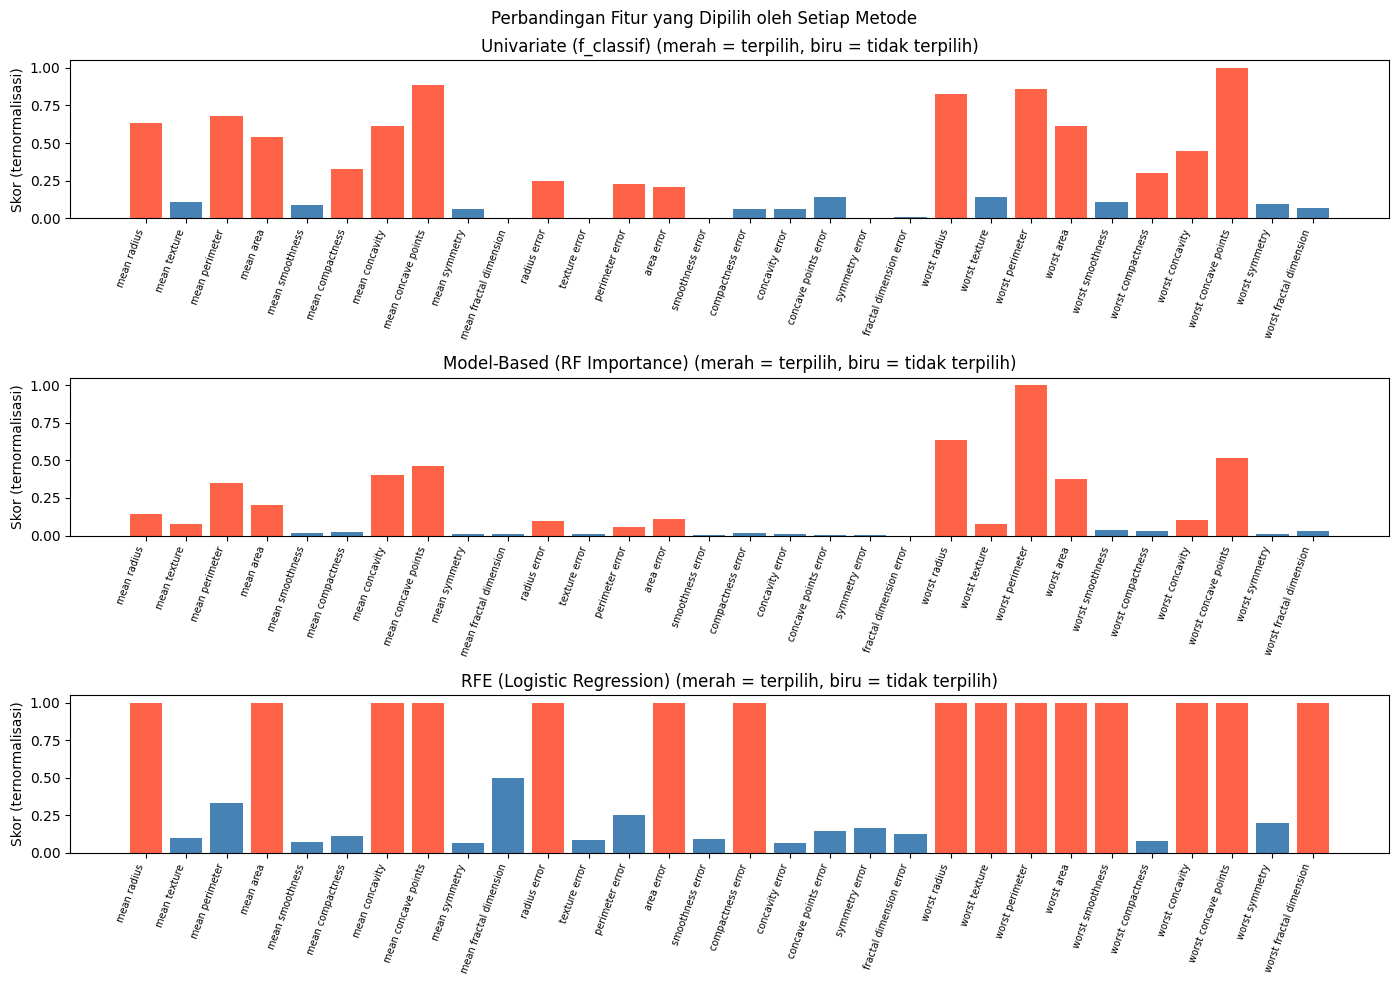

In [69]:
# Visualisasi fitur yang dipilih oleh setiap metode
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

methods = [
    ("Univariate (f_classif)", select_uni.get_support(), uni_scores),
    ("Model-Based (RF Importance)", select_model.get_support(), rf_importances),
    ("RFE (Logistic Regression)", rfe.get_support(), None),
]

for ax, (method_name, support, scores) in zip(axes, methods):
    colors_bar = ["tomato" if s else "steelblue" for s in support]
    if scores is not None:
        vals = scores.values
        norm_vals = (vals - vals.min()) / (vals.max() - vals.min() + 1e-8)
    else:
        # Untuk RFE gunakan ranking (dibalik agar fitur terpilih punya nilai tinggi)
        ranking = rfe.ranking_
        norm_vals = 1 / ranking

    ax.bar(range(len(support)), norm_vals, color=colors_bar, edgecolor="none")
    ax.set_xticks(range(len(support)))
    ax.set_xticklabels(cancer.feature_names, rotation=70, ha="right", fontsize=7)
    ax.set_title(f"{method_name} (merah = terpilih, biru = tidak terpilih)")
    ax.set_ylabel("Skor (ternormalisasi)")

plt.suptitle("Perbandingan Fitur yang Dipilih oleh Setiap Metode", fontsize=12)
plt.tight_layout()
plt.show()


## 4.8 Menggabungkan Preprocessing dalam Pipeline

Dalam praktik, semua langkah preprocessing harus digabungkan dalam Pipeline
untuk memastikan tidak ada data leakage dan kode lebih rapi.


In [70]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Contoh pipeline lengkap dengan semua preprocessing
pipe_full = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("poly",    PolynomialFeatures(degree=2, include_bias=False)),
    ("select",  SelectKBest(f_classif, k=20)),
    ("clf",     LogisticRegression(max_iter=5000, C=1)),
])

cancer = load_breast_cancer()
X_tr, X_te, y_tr, y_te = train_test_split(
    cancer.data, cancer.target, random_state=42, stratify=cancer.target)

pipe_full.fit(X_tr, y_tr)
print("Pipeline lengkap berhasil dilatih.")
print(f"Langkah-langkah pipeline:")
for i, (name, step) in enumerate(pipe_full.steps):
    print(f"  {i+1}. {name}: {type(step).__name__}")
print()
print(f"Test accuracy: {pipe_full.score(X_te, y_te):.4f}")
print()
print("Keunggulan Pipeline:")
print("  - Semua preprocessing di-fit hanya pada data training")
print("  - Data test ditransformasi menggunakan parameter dari training")
print("  - Tidak ada kemungkinan data leakage")
print("  - Kode lebih rapi dan reproducible")


Pipeline lengkap berhasil dilatih.
Langkah-langkah pipeline:
  1. imputer: SimpleImputer
  2. scaler: StandardScaler
  3. poly: PolynomialFeatures
  4. select: SelectKBest
  5. clf: LogisticRegression

Test accuracy: 0.9790

Keunggulan Pipeline:
  - Semua preprocessing di-fit hanya pada data training
  - Data test ditransformasi menggunakan parameter dari training
  - Tidak ada kemungkinan data leakage
  - Kode lebih rapi dan reproducible


## 4.9 Ringkasan

### Variabel Kategorikal

| Encoding | Kapan Digunakan | Contoh |
|----------|----------------|--------|
| One-Hot Encoding | Variabel nominal (tidak berurutan) | kota, warna, jenis kelamin |
| Ordinal Encoding | Variabel ordinal (berurutan) | pendidikan, rating, ukuran |

### Transformasi Fitur

| Teknik | Tujuan | Cocok untuk |
|--------|--------|-------------|
| Binning | Tangkap non-linearity dengan model linear | Fitur kontinu, model linear |
| Polynomial Features | Interaksi dan non-linearity | Model linear, dataset kecil |
| log1p / sqrt | Normalisasi distribusi skewed | Harga, hitungan, pendapatan |

### Seleksi Fitur

| Metode | Kecepatan | Tangkap Interaksi | Kapan Digunakan |
|--------|-----------|-------------------|----------------|
| Univariate | Sangat cepat | Tidak | Baseline, data sangat besar |
| Model-Based | Sedang | Ya | Default yang baik |
| RFE | Lambat | Ya | Butuh subset fitur optimal |

### Tips Praktis

1. Selalu gunakan Pipeline untuk mencegah data leakage.
2. One-Hot Encoding untuk nominal, Ordinal untuk ordinal.
3. Tree-based model tidak butuh scaling atau transformasi log.
4. Polynomial features bisa sangat membantu model linear pada data non-linear.
5. Seleksi fitur membantu jika jumlah fitur >> jumlah sampel.
